In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ['GOOGLE_API_KEY'] = os.getenv('GOOGLE_API_KEY')
os.environ['HF_TOKEN'] = os.getenv('HUGGINGFACE_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

In [3]:
def function_1(input_1):
    return input_1 + " First Function "

def function_2(input_2):
    return input_2 + "to Second Function"

In [33]:
from langgraph.graph import StateGraph
from typing import TypedDict

# Define the state
class State(TypedDict):
    input: str
    output: str

# Create a StateGraph
workflow1 = StateGraph(State)

# Add nodes (updated to accept state parameter)
def node_1_updated(state):
    result = state["input"] + " First Function "
    return {"output": result}

def node_2_updated(state):
    result = state["output"] + "to Second Function"
    return {"output": result}

workflow1.add_node("node_1", node_1_updated)
workflow1.add_node("node_2", node_2_updated)

workflow1.add_edge('node_1', 'node_2')

workflow1.set_entry_point("node_1")
workflow1.set_finish_point("node_2")

app1 = workflow1.compile()


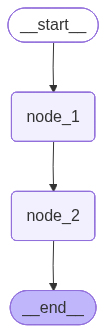

In [34]:
from IPython.display import display
display(app)


In [39]:
app1.invoke({"input": "Hello,"})

{'input': 'Hello,', 'output': 'Hello, First Function to Second Function'}

In [38]:
app1.invoke({"input": "Hello,"})['output']

'Hello, First Function to Second Function'

In [40]:
input = "Hello,"

In [44]:
for output in app1.stream({"input": input}):
    for key,value in output.items():
        print(f"{key}: {value}")

node_1: {'output': 'Hello, First Function '}
node_2: {'output': 'Hello, First Function to Second Function'}


### Now Workflow wit LLM

In [45]:
from langchain_huggingface import HuggingFaceEmbeddings
embedding = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

c:\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1946.72it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [46]:
def node_1_new1(state):
    llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
    result = llm.invoke(state["input"]).content
    return {"output": result}

In [47]:
def node_2_new2(state):
    res = state["output"].upper()
    return {"output": res}

In [48]:
workflow2 = StateGraph(State)
workflow2.add_node("llm", node_1_new1)
workflow2.add_node("UPPER", node_2_new2)

workflow2.add_edge('llm', 'UPPER')

workflow2.set_entry_point("llm")
workflow2.set_finish_point("UPPER")

In [49]:
app2 = workflow2.compile()

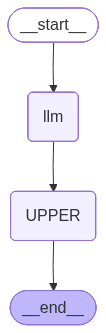

In [50]:
display(app2)

In [51]:
input2 = "Tell About Economic Growth in India"

In [52]:
app2.invoke({"input": input2})

{'input': 'Tell About Economic Growth in India',
 'output': 'INDIA\'S ECONOMIC GROWTH STORY IS ONE OF THE MOST DYNAMIC AND SIGNIFICANT IN THE GLOBAL ECONOMY. OVER THE PAST FEW DECADES, IT HAS TRANSFORMED FROM A LARGELY AGRARIAN, SOCIALIST-LEANING ECONOMY TO A FAST-GROWING, MARKET-ORIENTED POWERHOUSE.\n\nHERE\'S A BREAKDOWN OF KEY ASPECTS OF INDIA\'S ECONOMIC GROWTH:\n\n## THE TRANSFORMATION: FROM "HINDU RATE OF GROWTH" TO GLOBAL PLAYER\n\n*   **PRE-1991:** FOR DECADES AFTER INDEPENDENCE, INDIA\'S ECONOMY GREW AT A SLOW PACE, OFTEN TERMED THE "HINDU RATE OF GROWTH" (AROUND 3-4% ANNUALLY). THIS WAS LARGELY DUE TO PROTECTIONIST POLICIES, STATE-LED INDUSTRIALIZATION, AND A COMPLEX LICENSE RAJ.\n*   **POST-1991 LIBERALIZATION:** THE ECONOMIC REFORMS INITIATED IN 1991 MARKED A WATERSHED MOMENT. THESE REFORMS INCLUDED OPENING UP THE ECONOMY TO FOREIGN INVESTMENT, REDUCING TARIFFS, PRIVATIZING STATE-OWNED ENTERPRISES, AND DEREGULATING INDUSTRIES. THIS UNLEASHED INDIA\'S ECONOMIC POTENTIAL.\n\n

In [53]:
for output in app2.stream({"input": input2}):
    for key,value in output.items():
        print(f"{key}: {value}")

llm: {'output': 'India\'s economic growth story is one of the most remarkable transformations in recent global history. From a largely agrarian, socialist-leaning economy struggling with slow growth for decades, it has emerged as one of the world\'s fastest-growing major economies and a significant global player.\n\nHere\'s a breakdown of India\'s economic growth:\n\n## 1. The Pre-Liberalization Era (Pre-1991): The "Hindu Rate of Growth"\n\nBefore 1991, India\'s economy was characterized by:\n*   **Centralized Planning:** A socialist-inspired model with significant state control.\n*   **Protectionism:** High tariffs and import restrictions to protect domestic industries.\n*   **License Raj:** Bureaucratic hurdles and extensive licensing requirements that stifled private enterprise.\n*   **Slow Growth:** Often referred to as the "Hindu Rate of Growth," averaging around 3-4% annually, which was barely above population growth, leading to limited improvements in living standards.\n*   **Fo

### Including RAG Pipeline 